# Demand Forecasting Analytical Report

This notebook documents EDA, de-censoring, backtesting, baseline comparison, and leakage validation.

In [1]:
import sys
sys.path.append('../..')

import pandas as pd
import matplotlib.pyplot as plt

from src.data_loading import load_data, validate_schema
from src.preprocessing import clean_data, sort_time_series, add_stockout_flag
from src.features import build_features
from src.decensoring import create_demand_proxy, summarize_censoring
from src.training import train_and_evaluate
from src.validation import evaluate_baselines, future_permutation_test, get_three_month_backtest_split

## 1. Load Data

In [2]:
# Update the path if your CSV file has a different name
DATA_PATH = '../data/demand_train_val_1.5years.csv'

df = load_data(DATA_PATH)
validate_schema(df)
df.head()

,timestamp,store_id,product_id,temperature,local_event_factor,price,is_promo,competitor_price,delivery_delay_hours,holiday_factor,app_clicks,stock_on_hand,sales
0,2025-01-01 00:00:00,1,101,-5.954893,1.0,45.0,0,39.389910,0,5.006914,32.0,127,8
1,2025-01-01 01:00:00,1,101,-8.221485,1.0,40.0,0,43.727214,0,3.950974,29.0,119,7
2,2025-01-01 02:00:00,1,101,-3.560772,1.0,45.0,0,44.890532,0,0.298087,0.0,112,0
3,2025-01-01 03:00:00,1,101,-3.737111,1.0,40.0,0,38.710237,0,4.320862,NaN,112,8
4,2025-01-01 04:00:00,1,101,0.748672,1.0,40.0,0,39.771702,0,0.303396,0.0,164,0


## 2. Exploratory Data Analysis

In [3]:
display(df.info())
display(df.isna().sum())
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 78486 entries, 0 to 78485
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             78486 non-null  datetime64[us]
 1   store_id              78486 non-null  int64         
 2   product_id            78486 non-null  int64         
 3   temperature           76601 non-null  float64       
 4   local_event_factor    78486 non-null  float64       
 5   price                 78486 non-null  float64       
 6   is_promo              78486 non-null  int64         
 7   competitor_price      66728 non-null  float64       
 8   delivery_delay_hours  78486 non-null  int64         
 9   holiday_factor        78486 non-null  float64       
 10  app_clicks            72117 non-null  float64       
 11  stock_on_hand         78486 non-null  int64         
 12  sales                 78486 non-null  int64         
dtypes: datetime64[us](1), float

None

timestamp                   0
store_id                    0
product_id                  0
temperature              1885
local_event_factor          0
price                       0
is_promo                    0
competitor_price        11758
delivery_delay_hours        0
holiday_factor              0
app_clicks               6369
stock_on_hand               0
sales                       0
dtype: int64

,timestamp,store_id,product_id,temperature,local_event_factor,price,is_promo,competitor_price,delivery_delay_hours,holiday_factor,app_clicks,stock_on_hand,sales
count,78486,78486.000000,78486.000000,76601.000000,78486.000000,78486.000000,78486.000000,66728.000000,78486.000000,78486.000000,72117.000000,78486.000000,78486.000000
mean,2025-09-30 12:00:00,2.000000,101.500000,12.515442,1.008352,54.961107,0.099801,54.543671,0.157098,1.040394,60.877851,2277.523138,4.778304
min,2025-01-01 00:00:00,1.000000,101.000000,-13.139321,1.000000,32.300000,0.000000,18.596486,0.000000,0.101622,0.000000,0.000000,0.000000
25%,2025-05-17 06:00:00,1.000000,101.000000,3.335653,1.000000,40.000000,0.000000,39.872501,0.000000,1.000000,8.000000,0.000000,0.000000
50%,2025-09-30 12:00:00,2.000000,101.500000,12.240861,1.000000,51.400000,0.000000,48.254966,0.000000,1.000000,34.000000,40.000000,0.000000
75%,2026-02-13 18:00:00,3.000000,102.000000,21.723555,1.000000,70.000000,0.000000,69.868410,0.000000,1.000000,87.000000,3341.000000,6.000000
max,2026-06-30 00:00:00,3.000000,102.000000,39.566022,2.997826,75.000000,1.000000,83.100223,4.000000,5.998728,2712.000000,16860.000000,426.000000
std,NaN,0.816502,0.500003,10.571100,0.107749,15.150477,0.299737,15.400801,0.553962,0.414814,82.679351,4053.017920,9.730403


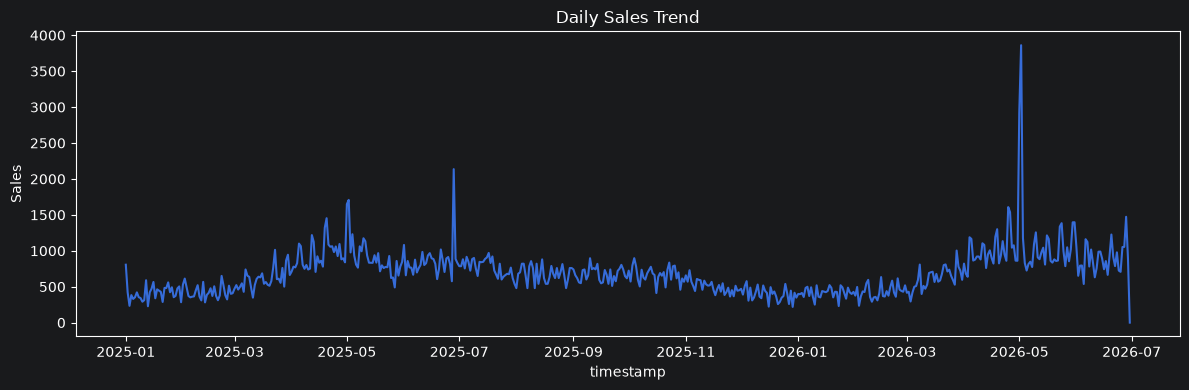

In [4]:
df.groupby(df['timestamp'].dt.date)['sales'].sum().plot(figsize=(12, 4), title='Daily Sales Trend')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

## 3. Preprocessing, Feature Engineering and De-censoring

In [5]:
df_clean = clean_data(df)
df_clean = sort_time_series(df_clean)
df_clean = add_stockout_flag(df_clean)
df_features = build_features(df_clean)
df_model = create_demand_proxy(df_features)

summarize_censoring(df_model)

{'total_rows': 78486, 'stockout_rows': 35381, 'stockout_share': 0.4508}

## 4. Three-Month Backtest

In [6]:
train_df, test_df = get_three_month_backtest_split(df_model, months=3)

baseline_results = evaluate_baselines(test_df, target_col='demand_proxy')
model, model_metrics, prediction_df = train_and_evaluate(train_df, test_df, target_col='demand_proxy')

model_results = pd.DataFrame([{'Model': 'LightGBM improved model', **model_metrics}])
comparison = pd.concat([baseline_results, model_results], ignore_index=True)
comparison

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001914 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2879
[LightGBM] [Info] Number of data points in the train set: 65232, number of used features: 23
[LightGBM] [Info] Start training from score 6.464473


,Model,MAE,RMSE
0,Naive Forecast (previous hour),6.47,12.19
1,Seasonal Naive Forecast (previous day),7.24,13.76
2,LightGBM improved model,1.10,4.88


## 5. Model Comparison Visualization

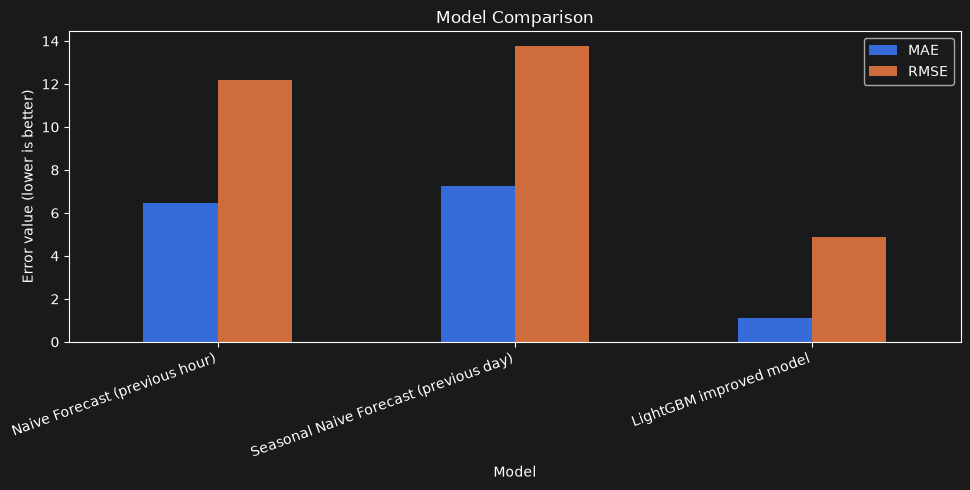

In [7]:
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison')
plt.ylabel('Error value (lower is better)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 6. Leakage Test Report

In [8]:
leakage_result = future_permutation_test(df_model)
leakage_result

{'test_name': 'Future Permutation Test',
 'passed': True,
 'checked_columns': ['sales_lag_1h',
  'sales_lag_24h',
  'sales_lag_168h',
  'sales_rolling_mean_24h',
  'sales_rolling_std_24h'],
 'explanation': 'Historical feature values did not change after future target permutation.'}

## 7. Business Summary

The model improves forecasting accuracy compared with naive baselines and can support inventory planning, purchasing decisions, and stock-out reduction.